Using Colab cache for faster access to the 'tomatoleaf' dataset.
Dataset downloaded at:
/kaggle/input/tomatoleaf

Dataset contents:
tomato

Dataset root:
/kaggle/input/tomatoleaf/tomato

Train directory:
/kaggle/input/tomatoleaf/tomato/train

Validation directory:
/kaggle/input/tomatoleaf/tomato/val

TRAINING PARAMETERS
Image size     : 128 x 128
Batch size     : 32
Maximum epochs : 30
Learning rate  : 0.001
Optimizer      : Adam
Found 10000 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.

CLASS INFORMATION
0 : Tomato___Bacterial_spot
1 : Tomato___Early_blight
2 : Tomato___Late_blight
3 : Tomato___Leaf_Mold
4 : Tomato___Septoria_leaf_spot
5 : Tomato___Spider_mites Two-spotted_spider_mite
6 : Tomato___Target_Spot
7 : Tomato___Tomato_Yellow_Leaf_Curl_Virus
8 : Tomato___Tomato_mosaic_virus
9 : Tomato___healthy

Number of classes: 10

DATASET SIZE
Training batches: 313
Validation batches: 32
Approx training images: 10016
Approx validation images: 1024


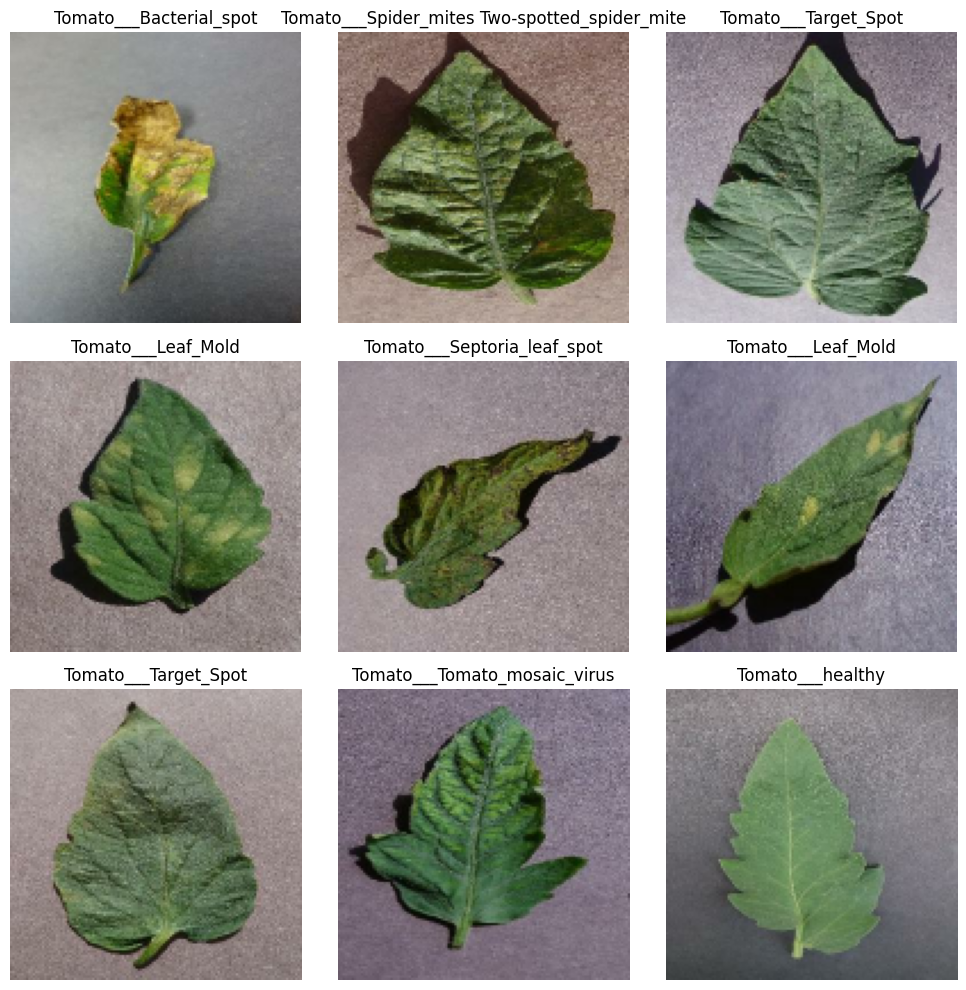

In [ ]:

!pip install -q kagglehub

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
import seaborn as sns

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)




SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)




path = kagglehub.dataset_download(
    "kaustubhb999/tomatoleaf"
)

print("Dataset downloaded at:")
print(path)

print("\nDataset contents:")

for item in os.listdir(path):
    print(item)

dataset_root = os.path.join(
    path,
    "tomato"
)

print("\nDataset root:")
print(dataset_root)




train_dir = os.path.join(
    dataset_root,
    "train"
)

val_dir = os.path.join(
    dataset_root,
    "val"
)

print("\nTrain directory:")
print(train_dir)

print("\nValidation directory:")
print(val_dir)


if not os.path.exists(train_dir):
    raise FileNotFoundError(
        f"Training directory not found: {train_dir}"
    )

if not os.path.exists(val_dir):
    raise FileNotFoundError(
        f"Validation directory not found: {val_dir}"
    )


IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 0.001



print("Image size     :", IMG_SIZE, "x", IMG_SIZE)
print("Batch size     :", BATCH_SIZE)
print("Maximum epochs :", EPOCHS)
print("Learning rate  :", LEARNING_RATE)
print("Optimizer      : Adam")


train_ds = tf.keras.utils.image_dataset_from_directory(

    train_dir,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED
)



val_ds = tf.keras.utils.image_dataset_from_directory(

    val_dir,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    shuffle=False
)




class_names = train_ds.class_names

num_classes = len(class_names)



for i, name in enumerate(class_names):
    print(i, ":", name)

print("\nNumber of classes:", num_classes)




train_batches = tf.data.experimental.cardinality(
    train_ds
).numpy()

val_batches = tf.data.experimental.cardinality(
    val_ds
).numpy()

print(
    "Training batches:",
    train_batches
)

print(
    "Validation batches:",
    val_batches
)

print(
    "Approx training images:",
    train_batches * BATCH_SIZE
)

print(
    "Approx validation images:",
    val_batches * BATCH_SIZE
)




data_augmentation = tf.keras.Sequential([

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.1
    ),

    layers.RandomZoom(
        0.1
    )
])


# ============================================================
# OPTIMIZE DATA PIPELINE
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(
    1000
).prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.cache().prefetch(
    buffer_size=AUTOTUNE
)




plt.figure(
    figsize=(10, 10)
)

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(
            3,
            3,
            i + 1
        )

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            class_names[
                labels[i]
            ]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:


model = models.Sequential([

    # Input layer
    layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    # Data augmentation
    data_augmentation,

    # Normalize pixel values: 0-255 -> 0-1
    layers.Rescaling(1.0 / 255),



    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),



    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),



    layers.Conv2D(
        256,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),



    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    # Dropout to reduce overfitting
    layers.Dropout(
        0.5
    ),

    # Output layer
    layers.Dense(
        num_classes,
        activation="softmax"
    )
])




print("\n========================================")
print("CNN MODEL ARCHITECTURE")
print("========================================")

model.summary()





optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)




model.compile(

    optimizer=optimizer,

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)




reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    min_lr=1e-6,

    verbose=1
)




print("\n========================================")
print("STARTING CNN TRAINING")
print("========================================")

history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=12,

    callbacks=[
        reduce_lr
    ]
)



actual_epochs = len(
    history.history["loss"]
)

best_epoch = (
    np.argmax(
        history.history["val_accuracy"]
    ) + 1
)

best_val_accuracy = max(
    history.history["val_accuracy"]
)

best_val_loss = min(
    history.history["val_loss"]
)


print("\n========================================")
print("TRAINING COMPLETED")
print("========================================")

print(
    "Maximum epochs        : 12"
)

print(
    "Actual epochs trained :",
    actual_epochs
)

print(
    "Best epoch            :",
    best_epoch
)

print(
    f"Best validation accuracy : "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    f"Best validation loss     : "
    f"{best_val_loss:.4f}"
)



model.save(
    "/content/tomato_disease_cnn.keras"
)

print(
    "\nModel saved successfully at:"
)

print(
    "/content/tomato_disease_cnn.keras"
)


CNN MODEL ARCHITECTURE


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,486,986 (9.49 MB)

 Trainable params: 2,486,986 (9.49 MB)

 Non-trainable params: 0 (0.00 B)


STARTING CNN TRAINING
Epoch 1/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.2771 - loss: 1.9513 - val_accuracy: 0.5610 - val_loss: 1.2698 - learning_rate: 0.0010
Epoch 2/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.5384 - loss: 1.2797 - val_accuracy: 0.6760 - val_loss: 0.9005 - learning_rate: 0.0010
Epoch 3/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6529 - loss: 0.9658 - val_accuracy: 0.6910 - val_loss: 0.8170 - learning_rate: 0.0010
Epoch 4/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7247 - loss: 0.7767 - val_accuracy: 0.7990 - val_loss: 0.5824 - learning_rate: 0.0010
Epoch 5/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7714 - loss: 0.6483 - val_accuracy: 0.7610 - val_loss: 0.7198 - learning_rate: 0.0010
Epoch 6/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8059 - loss: 0.5678 - val_accuracy: 0.8570 - val_loss: 0.4543 - learning_rate: 0.0010
Epoch 7/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - acc

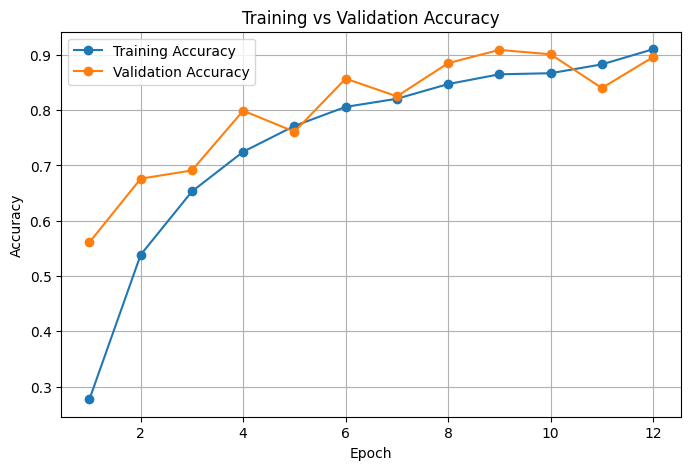

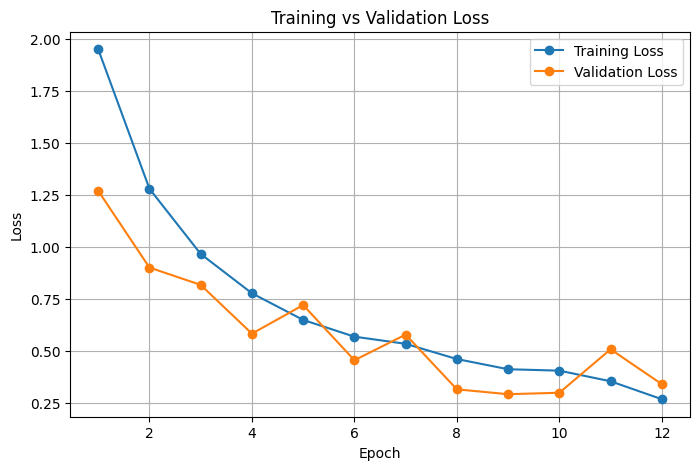

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8960 - loss: 0.3390

FINAL MODEL PERFORMANCE
Validation Loss     : 0.3390
Validation Accuracy : 0.8960
Validation Accuracy : 89.60%

Best Epoch:
9
Best Validation Accuracy: 90.90%

CLASSIFICATION REPORT
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot     0.9592    0.9400    0.9495       100
                        Tomato___Early_blight     0.8018    0.8900    0.8436       100
                         Tomato___Late_blight     0.9362    0.8800    0.9072       100
                           Tomato___Leaf_Mold     0.8349    0.9100    0.8708       100
                  Tomato___Septoria_leaf_spot     0.7680    0.9600    0.8533       100
Tomato___Spider_mites Two-spotted_spider_mite     0.9500    0.7600    0.8444       100
                         Tomato___Target_Spot     0.9195    0.8000    0.8556       100
       Tomato___Tomato_Yellow_Leaf_Curl_Virus 

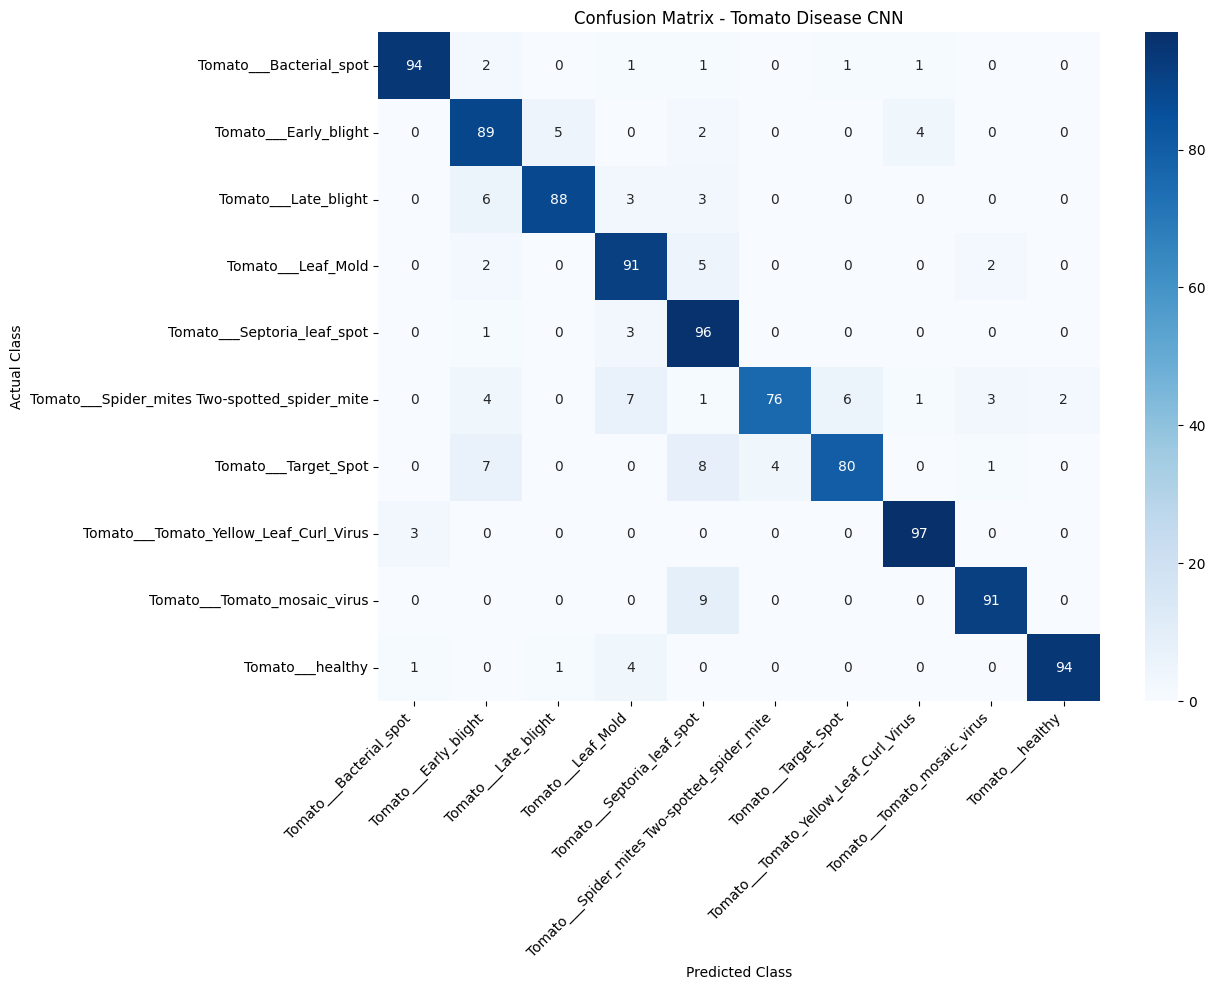

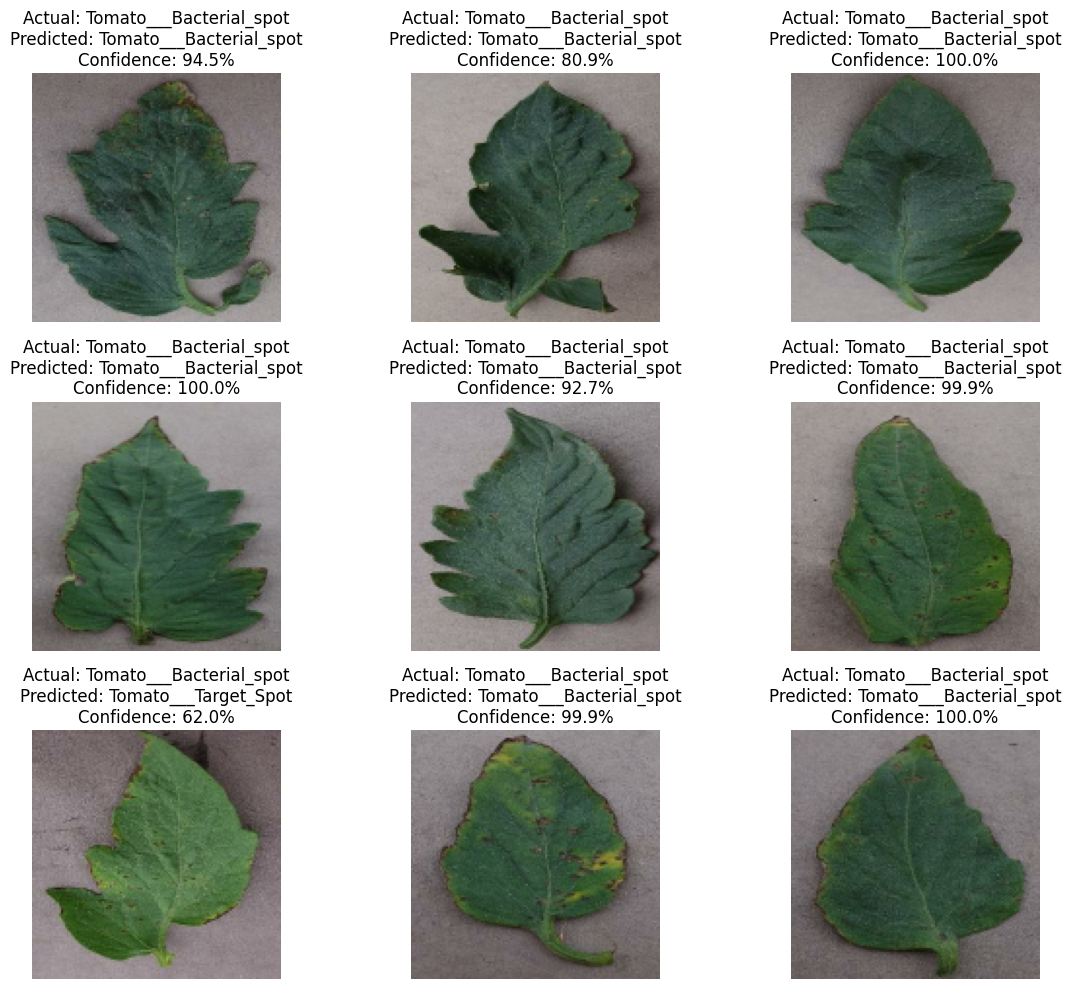


CNN ASSIGNMENT SUMMARY
Dataset              : Tomato Leaf Disease
Number of Classes    : 10
Image Size           : 128 x 128
Batch Size           : 32
Epochs               : 12
Optimizer            : Adam
Learning Rate        : 0.001
Final Validation Accuracy : 89.60%
Best Validation Accuracy  : 90.90%
Best Epoch           : 9


In [ ]:


plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(history.history["accuracy"]) + 1),
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    range(1, len(history.history["val_accuracy"]) + 1),
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()



plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(history.history["loss"]) + 1),
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, len(history.history["val_loss"]) + 1),
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()





val_loss, val_accuracy = model.evaluate(
    val_ds,
    verbose=1
)

print("\n========================================")
print("FINAL MODEL PERFORMANCE")
print("========================================")

print(
    f"Validation Loss     : {val_loss:.4f}"
)

print(
    f"Validation Accuracy : {val_accuracy:.4f}"
)

print(
    f"Validation Accuracy : {val_accuracy * 100:.2f}%"
)




best_epoch = (
    np.argmax(
        history.history["val_accuracy"]
    ) + 1
)

best_accuracy = max(
    history.history["val_accuracy"]
)

print("\nBest Epoch:")
print(best_epoch)

print(
    f"Best Validation Accuracy: "
    f"{best_accuracy * 100:.2f}%"
)




y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_classes
    )


y_true = np.array(y_true)
y_pred = np.array(y_pred)




print("\n========================================")
print("CLASSIFICATION REPORT")
print("========================================")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)



cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(13, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Confusion Matrix - Tomato Disease CNN"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.show()




plt.figure(figsize=(12, 10))

for images, labels in val_ds.take(1):

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    for i in range(
        min(9, len(images))
    ):

        plt.subplot(
            3,
            3,
            i + 1
        )

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        actual = class_names[
            labels[i]
        ]

        predicted = class_names[
            predicted_classes[i]
        ]

        confidence = (
            np.max(
                predictions[i]
            ) * 100
        )

        plt.title(
            f"Actual: {actual}\n"
            f"Predicted: {predicted}\n"
            f"Confidence: {confidence:.1f}%"
        )

        plt.axis("off")

plt.tight_layout()

plt.show()




print("\n========================================")
print("CNN ASSIGNMENT SUMMARY")
print("========================================")

print("Dataset              : Tomato Leaf Disease")
print("Number of Classes    :", num_classes)
print("Image Size           :", f"{IMG_SIZE} x {IMG_SIZE}")
print("Batch Size           :", BATCH_SIZE)
print("Epochs               :", 12)
print("Optimizer            : Adam")
print("Learning Rate        :", LEARNING_RATE)

print(
    f"Final Validation Accuracy : "
    f"{val_accuracy * 100:.2f}%"
)

print(
    f"Best Validation Accuracy  : "
    f"{best_accuracy * 100:.2f}%"
)

print(
    "Best Epoch           :",
    best_epoch
)

In [ ]:
print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())

print("Batch size:", BATCH_SIZE)

print("Approx training images:",
      tf.data.experimental.cardinality(train_ds).numpy() * BATCH_SIZE)

print("Approx validation images:",
      tf.data.experimental.cardinality(val_ds).numpy() * BATCH_SIZE)

Training batches: 25
Validation batches: 7
Batch size: 32
Approx training images: 800
Approx validation images: 224
